In [1]:
import numpy as np
import math
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import t
import plot_utils as pu

In [2]:
pu.apply_plot_style()

In [3]:
PROJECT_ROOT = (Path(__vsc_ipynb_file__).parents[1] / "scripts/benchmarks/simu_times")
P_100 = PROJECT_ROOT / "P100"
GTX_1070 = PROJECT_ROOT / "GTX1070"


In [4]:
def list_runs(dir):
    return sorted({
        p for p in Path(dir).rglob("*.csv")
    })

def read_all_runs(files):
    dfs = []
    for file in files:
        df = pd.read_csv(file)
        df["source_file"] = file.name
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True)

In [5]:
all_runs = list_runs(P_100)
runs_df = read_all_runs(all_runs)

In [6]:
runs_df.sample(10)

,scene_id,backend,variant,num_systems,systems_per_block,kernel_steps,max_registers,seed,mean_step_time_s,std_step_time_s,mean_launch_time_s,mean_launches_per_step,source_file
150,2B_TYPICAL,numba,shared,512,128,512,64,11,0.673471,0.000070,0.134694,5.0,2B_TYPICAL_numba_shared_nvrtc_ns_spb128_ks512_...
1332,3B_TYPICAL,numba,shared,16384,64,512,128,11,5.004515,0.002447,0.714931,7.0,3B_TYPICAL_numba_shared_nvrtc_ns_spb64_ks512_r...
34,2B_TYPICAL,numba,shared,8192,128,512,128,89,1.220909,0.000712,0.244182,5.0,2B_TYPICAL_numba_shared_nvrtc_ns_spb128_ks512_...
724,2B_TYPICAL,numba,warp,256,128,512,64,89,0.680996,0.000130,0.136199,5.0,2B_TYPICAL_numba_warp_nvrtc_ns_spb128_ks512_r6...
1460,3B_TYPICAL,numba,warp,2048,128,512,128,55,1.490491,0.000179,0.248415,6.0,3B_TYPICAL_numba_warp_nvrtc_ns_spb128_ks512_r1...
1925,3B_TYPICAL,numba,warp,256,64,512,192,119,0.942553,0.000108,0.157092,6.0,3B_TYPICAL_numba_warp_nvrtc_ns_spb64_ks512_r19...
1721,3B_TYPICAL,numba,warp,16384,16,512,64,119,6.289532,0.017703,0.898505,7.0,3B_TYPICAL_numba_warp_nvrtc_ns_spb16_ks512_r64...
1199,3B_TYPICAL,numba,shared,32768,32,512,128,119,7.379598,0.010905,1.054228,7.0,3B_TYPICAL_numba_shared_nvrtc_ns_spb32_ks512_r...
155,2B_TYPICAL,numba,shared,512,128,512,64,119,0.658089,0.000082,0.131618,5.0,2B_TYPICAL_numba_shared_nvrtc_ns_spb128_ks512_...
339,2B_TYPICAL,numba,shared,256,32,512,64,77,0.562155,0.000167,0.112431,5.0,2B_TYPICAL_numba_shared_nvrtc_ns_spb32_ks512_r...


In [7]:
def aggregate_for_plot(
    runs_df,
    backend="numba",
    variant="warp",
    metric="mean_step_time_s",
    ci=0.95,
):
    required_cols = {
        "scene_id",
        "backend",
        "variant",
        "num_systems",
        "systems_per_block",
        "kernel_steps",
        "max_registers",
        "seed",
        metric,
    }

    missing = required_cols - set(runs_df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df = runs_df[
        (runs_df["backend"] == backend) &
        (runs_df["variant"] == variant)
    ].copy()

    group_cols = [
        "scene_id",
        "backend",
        "variant",
        "num_systems",
        "systems_per_block",
        "kernel_steps",
        "max_registers",
    ]

    out = (
        df
        .groupby(group_cols, dropna=False)
        .agg(
            metric_mean=(metric, "mean"),
            metric_std_seed_means=(metric, lambda x: x.std(ddof=1)),
            metric_median=(metric, "median"),
            metric_min=(metric, "min"),
            metric_max=(metric, "max"),
            n_runs=(metric, "size"),
            n_seeds=("seed", "nunique"),
        )
        .reset_index()
    )

    out["metric_sem"] = out["metric_std_seed_means"] / np.sqrt(out["n_seeds"])

    alpha = 1.0 - ci
    out["tcrit"] = t.ppf(
        1.0 - alpha / 2.0,
        df=out["n_seeds"] - 1,
    )

    out["metric_ci95_half_width"] = out["tcrit"] * out["metric_sem"]
    out["metric_ci95_low"] = out["metric_mean"] - out["metric_ci95_half_width"]
    out["metric_ci95_high"] = out["metric_mean"] + out["metric_ci95_half_width"]

    out.loc[out["n_seeds"] <= 1, [
        "metric_std_seed_means",
        "metric_sem",
        "tcrit",
        "metric_ci95_half_width",
        "metric_ci95_low",
        "metric_ci95_high",
    ]] = np.nan

    out = out.sort_values(
        [
            "scene_id",
            "systems_per_block",
            "kernel_steps",
            "max_registers",
            "num_systems",
        ]
    ).reset_index(drop=True)

    return out
    

In [8]:
plot_df = aggregate_for_plot(runs_df, "numba", "warp", "mean_step_time_s")


In [9]:
plot_df.head(3)

,scene_id,backend,variant,num_systems,systems_per_block,kernel_steps,max_registers,metric_mean,metric_std_seed_means,metric_median,metric_min,metric_max,n_runs,n_seeds,metric_sem,tcrit,metric_ci95_half_width,metric_ci95_low,metric_ci95_high
0,2B_TYPICAL,numba,warp,256,32,512,32,0.990255,0.015012,0.988822,0.965395,1.007565,6,6,0.006129,2.570582,0.015754,0.974501,1.006009
1,2B_TYPICAL,numba,warp,512,32,512,32,0.986919,0.012246,0.988095,0.967448,1.000508,6,6,0.004999,2.570582,0.012852,0.974067,0.999770
2,2B_TYPICAL,numba,warp,1024,32,512,32,0.998189,0.010316,0.999602,0.980351,1.010512,6,6,0.004212,2.570582,0.010826,0.987363,1.009015


In [40]:
REG_COLOR_MAP = {
    32:  "tab:blue",
    64:  "tab:orange",
    128: "tab:green",
    192: "tab:red",
}

SPB_MARKER_MAP = {
    16: "o",
    32: "s",
    64: "^",
    128: "D",
}


def plot_scaling_ci_mixed_markers(
    plot_df,
    scene_id,
    systems_per_blocks=None,
    max_registers=None,
    kernel_steps=512,
    backend="numba",
    variant="warp",
    x_col="num_systems",
    y_col="metric_mean",
    yerr_col="metric_ci95_half_width",
    log_x=True,
    log_y=False,
    figsize=(8.0, 5.0),
    marker_size=6,
    line_width=1.4,
    error_line_width=1.0,
    capsize=3,
    capthick=1.0,
    errorbar_scale=1.0,
    show_errorbar=True,
    title=None,
    ax=None,
):
    """
    Egyetlen ábrára rajzolja az összes kiválasztott
    systems_per_block × max_registers kombinációt.

    Mapping:
        color  = max_registers
        marker = systems_per_block
        x      = num_systems
        y      = metric_mean
        yerr   = metric_ci95_half_width * errorbar_scale
    """

    required_cols = {
        "scene_id",
        "backend",
        "variant",
        "kernel_steps",
        "systems_per_block",
        "max_registers",
        x_col,
        y_col,
        yerr_col,
    }

    missing = required_cols - set(plot_df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    df = plot_df[
        (plot_df["scene_id"] == scene_id)
        & (plot_df["backend"] == backend)
        & (plot_df["variant"] == variant)
        & (plot_df["kernel_steps"] == kernel_steps)
    ].copy()

    if systems_per_blocks is not None:
        df = df[df["systems_per_block"].isin(systems_per_blocks)]

    if max_registers is not None:
        df = df[df["max_registers"].isin(max_registers)]

    if df.empty:
        raise ValueError(
            f"No data for scene_id={scene_id}, backend={backend}, "
            f"variant={variant}, kernel_steps={kernel_steps}, "
            f"systems_per_blocks={systems_per_blocks}, max_registers={max_registers}"
        )

    spbs = sorted(df["systems_per_block"].dropna().unique())
    regs = sorted(df["max_registers"].dropna().unique())

    marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "*"]
    marker_map = {
        spb: marker_cycle[i % len(marker_cycle)]
        for i, spb in enumerate(spbs)
    }

    palette = sns.color_palette("viridis", n_colors=len(regs))
    color_map = {
        reg: palette[i]
        for i, reg in enumerate(regs)
    }

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    for (spb, reg), g in df.groupby(["systems_per_block", "max_registers"]):
        g = g.sort_values(x_col)

        #color = color_map[reg]
        #marker = marker_map[spb]

        color = REG_COLOR_MAP[reg]
        marker = SPB_MARKER_MAP[spb]

        if show_errorbar:
            yerr = g[yerr_col].to_numpy(dtype=float) * errorbar_scale
        else:
            yerr = None

        ax.errorbar(
            g[x_col],
            g[y_col],
            yerr=yerr,
            marker=marker,
            markersize=marker_size,
            linestyle="-",
            linewidth=line_width,
            capsize=capsize if show_errorbar else 0,
            capthick=capthick,
            elinewidth=error_line_width,
            color=color,
            alpha=0.95,
            label=f"spb={spb}, r={reg}",
        )

    if log_x:
        ax.set_xscale("log", base=2)

        #xticks = sorted(df[x_col].dropna().unique())
        #ax.set_xticks(xticks)

        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, pos: f"{int(x):d}")
        )
        ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    if log_y:
        ax.set_yscale("log")

    ax.set_xlabel("Number of systems")
    ax.set_ylabel("Mean step time [s]")

    ax.set_xlabel("Number of systems")
    ax.set_ylabel("Mean step time [s]")

    ax.tick_params(axis="both")

    if title is None:
        title = f"{scene_id} | {backend} | {variant} | ks={kernel_steps}"
        if show_errorbar and errorbar_scale != 1.0:
            title += f" | CI ×{errorbar_scale:g}"

    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)

    # Két külön legenda: color = register, marker = SPB
    color_handles = [
        plt.Line2D(
            [0],
            [0],
            color=REG_COLOR_MAP[reg],
            marker=None,
            linestyle="-",
            linewidth=line_width,
            markersize=marker_size,
            label=f"{reg}",
        )
        for reg in regs
    ]

    marker_handles = [
        plt.Line2D(
            [0],
            [0],
            color="black",
            marker=SPB_MARKER_MAP[spb],
            linestyle="None",
            markersize=marker_size,
            label=f"{spb}",
        )
        for spb in spbs
    ]

    leg1 = ax.legend(
        handles=color_handles,
        title="Max registers",
        loc="upper left",
        bbox_to_anchor=(0.02, 0.98),
        borderaxespad=0,
        #fontsize=8,
        #title_fontsize=10
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=marker_handles,
        title="SPB",
        loc="upper left",
        bbox_to_anchor=(0.42, 0.98),
        borderaxespad=0,
        #fontsize=8,
        #title_fontsize=10
    )

    fig.tight_layout()

    return fig, ax

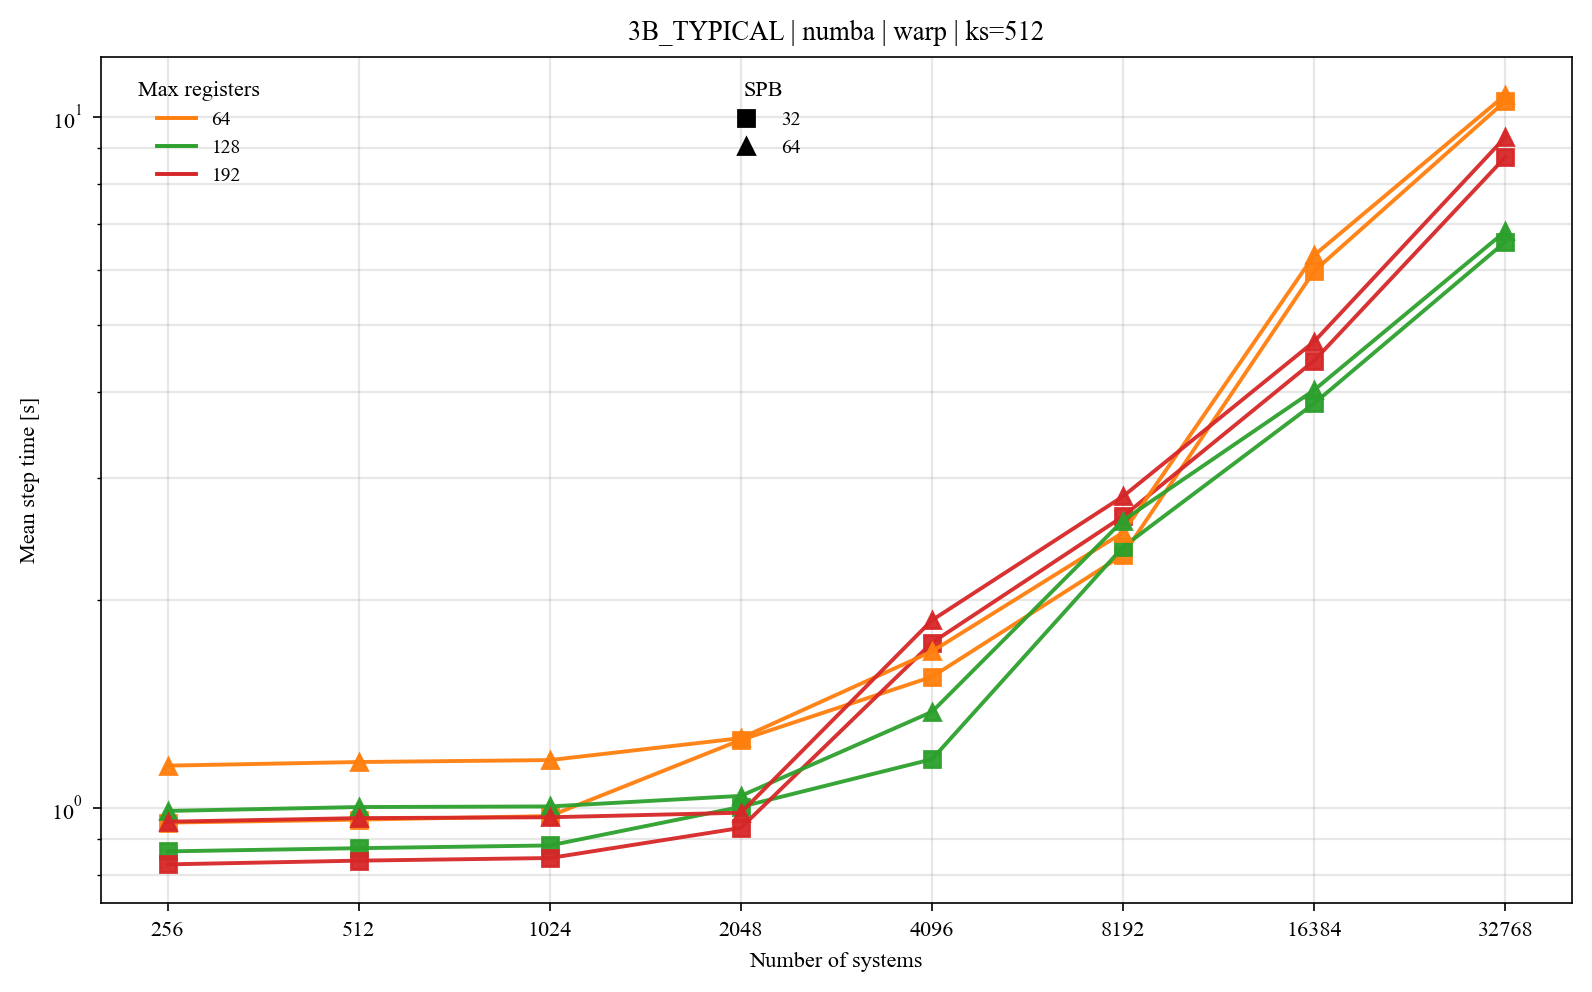

In [41]:
fig, ax = plot_scaling_ci_mixed_markers(
    plot_df,
    scene_id="3B_TYPICAL",
    systems_per_blocks=[32, 64],
    max_registers=[32, 64, 128, 192],
    kernel_steps=512,
    backend="numba",
    variant="warp",
    errorbar_scale=100,
    show_errorbar=False,
    log_y=True
)

C:\Users\Kalman\AppData\Local\Temp\ipykernel_21608\975235543.py:217: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


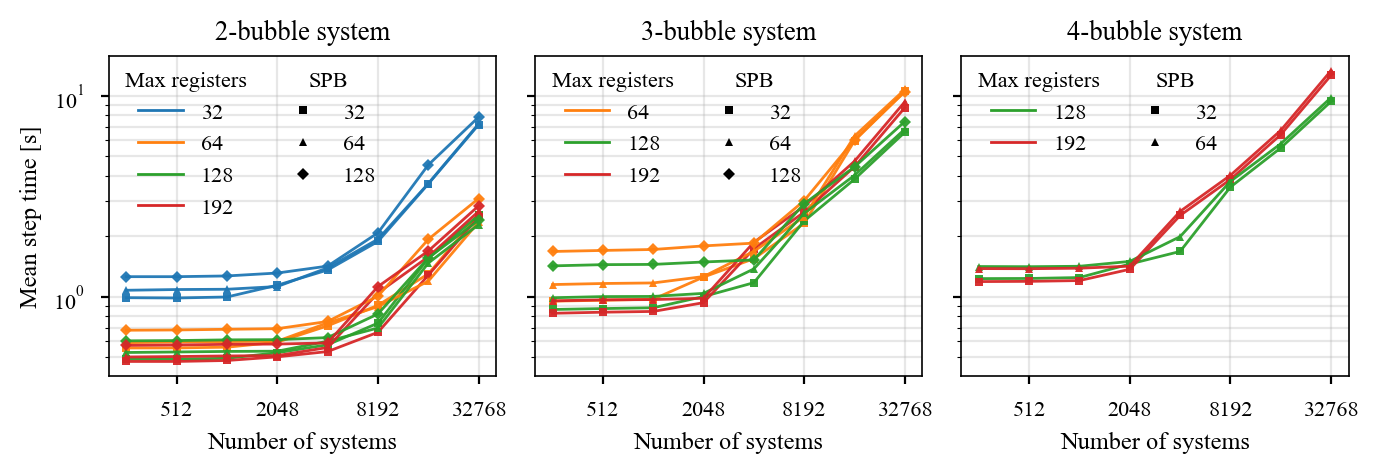

In [43]:
(fig_w, fig_h), adj = pu.two_column_figsize(
    1, 3,
    width_in=7.0,
    panel_height_in=1.60,
    wspace=0.1,
    hspace=0.20,
)

with plt.style.context("seaborn-v0_8-paper"):
    fig, axes = plt.subplots(
        1, 3,
        figsize=(fig_w, fig_h),
        sharey=True,
        constrained_layout=True,
    )

    scenes = ["2B_TYPICAL", "3B_TYPICAL", "4B_TYPICAL"]

    bub = 2
    for ax, scene_id in zip(axes, scenes):
        plot_scaling_ci_mixed_markers(
            plot_df,
            scene_id=scene_id,
            systems_per_blocks=[32, 64, 128],
            max_registers=[32, 64, 128, 192],
            kernel_steps=512,
            backend="numba",
            variant="warp",
            line_width=1.0,
            marker_size=3,
            show_errorbar=False,
            ax=ax,
            title=scene_id,
            log_y=True
        )

        ax.set_title(f"{bub}-bubble system")
        bub += 1

    axes[0].set_ylabel("Mean step time [s]")

    for ax in axes[1:]:
        ax.set_ylabel("")

fig.subplots_adjust(**adj)
fig.savefig("figs/fig_comp_perf.pdf", bbox_inches="tight")
fig.savefig("figs/fig_comp_perf.png", dpi=300, bbox_inches="tight")
plt.show()